In [6]:
import xarray as xr
import matplotlib.pyplot as plt
from dask.distributed import Client
import matplotlib.animation as animation
import numpy as np
import os
import xesmf as xe
import intake

In [7]:
client = Client(threads_per_worker=1)
#client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36855 instead
  warnings.warn(


## files
daily data for sots sub-region (depth, lat, long, time)
- `access-om3.mom6.region.3d.salt.z.1day.mean._2170.nc` 
- `access-om3.mom6.region.3d.temp.z.1day.mean._2170.nc`
- `access-om3.mom6.region.3d.uo.z.1day.mean._2170.nc`
- `access-om3.mom6.region.3d.vo.z.1day.mean._2170.nc`
  
daily surface data for whole model (lat, long, time)
- `access-om3.mom6.2d.1day.mean._2170.nc`
  
daily surface flux data for whole model (lat, long, time)
- `access-om3.mom6.flux.2d.1day.mean._2170.nc`

In [ ]:
# # Open dataset
base_dir = "/g/data/jk72/mxr581/SOTS-project-data/regional-model-output/output008/"
ds_surf = xr.open_dataset(os.path.join(base_dir, "access-om3.mom6.2d.1day.mean._2170.nc"))

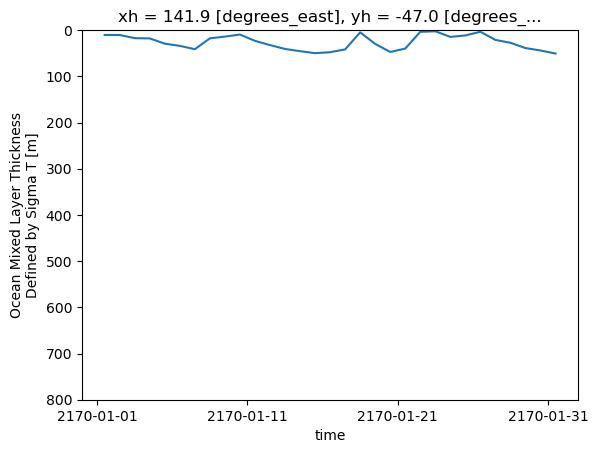

In [50]:
ds_surf.mlotst.sel(xh = 141.9, yh = -47, method = 'nearest').plot(ylim = [800, 0])

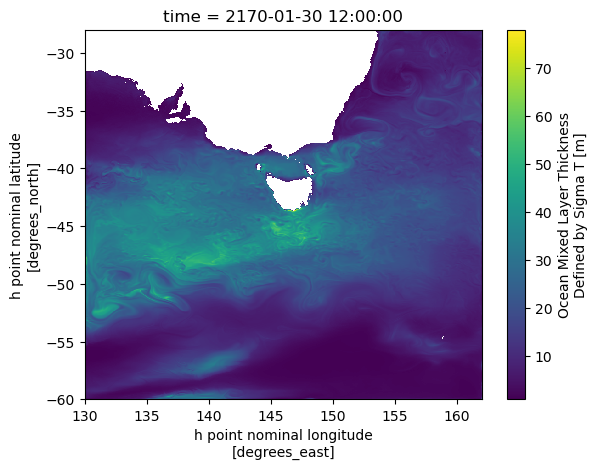

In [52]:
ds_surf.mlotst.isel(time = -2).plot()

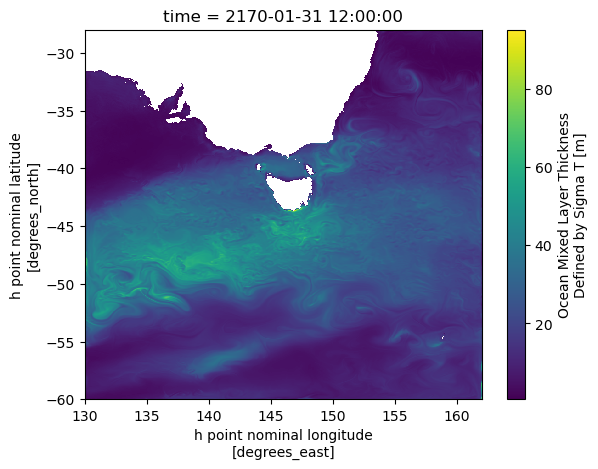

In [53]:
ds_surf.mlotst.isel(time = -1).plot()

In [14]:
# # Open datasets
base_dir = "/home/581/mxr581/access-om3/se-aus-om2-forced-ryf/archive/output008"
ds = xr.open_dataset(os.path.join(base_dir, "access-om3.mom6.region.3d.temp.z.1day.mean._2170.nc"))

/jobfs/156253500.gadi-pbs/ipykernel_3054949/1862225879.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(base_dir, "access-om3.mom6.region.3d.temp.z.1day.mean._2170.nc"))


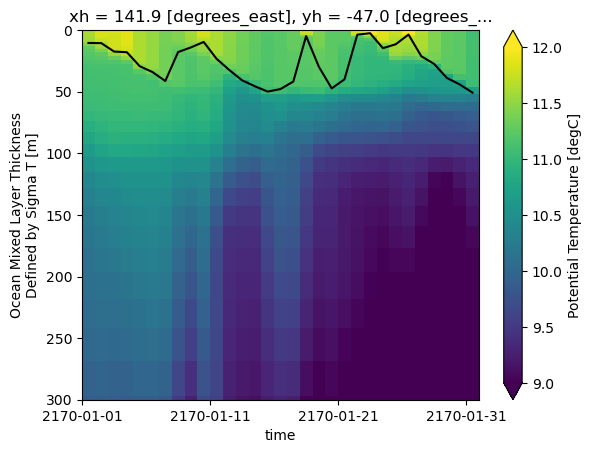

In [40]:
ds.temp.isel(xh_sub02 = 25, yh_sub02 = 33).sel(z_l = slice (0, 900)).plot(x = "time", y = "z_l", ylim = [300, 0], vmin = 9, vmax = 12)
ds_surf.mlotst.sel(xh = 141.9, yh = -47, method = 'nearest').plot(color = 'k')

In [41]:
# # Open datasets
base_dir = "/home/581/mxr581/access-om3/se-aus-om2-forced-ryf/archive/output008"
ds_surf_flux = xr.open_dataset(os.path.join(base_dir, "access-om3.mom6.flux.2d.1day.mean._2170.nc"))

/jobfs/156253500.gadi-pbs/ipykernel_3054949/3716196716.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_surf_flux = xr.open_dataset(os.path.join(base_dir, "access-om3.mom6.flux.2d.1day.mean._2170.nc"))


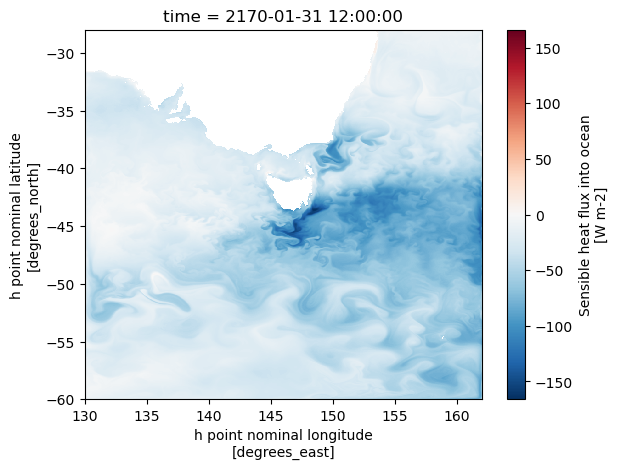

In [43]:
ds_surf_flux.sensible.isel(time = -1).plot()

In [44]:
# # Open datasets
base_dir = "/home/581/mxr581/access-om3/se-aus-om2-forced-ryf/archive/output008"
ds_monthly3d= xr.open_dataset(os.path.join(base_dir, "access-om3.mom6.3d.1mon.mean._2170.nc"))

/jobfs/156253500.gadi-pbs/ipykernel_3054949/1475704626.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_monthly3d= xr.open_dataset(os.path.join(base_dir, "access-om3.mom6.3d.1mon.mean._2170.nc"))


In [46]:
ds_monthly3d.rhopot2

<xarray.DataArray 'rhopot2' (time: 1, z_l: 75, yh: 1202, xh: 864)> Size: 312MB
[77889600 values with dtype=float32]
Coordinates:
  * xh       (xh) float64 7kB 130.0 130.1 130.1 130.1 ... 161.9 161.9 162.0
  * yh       (yh) float64 10kB -59.99 -59.96 -59.93 ... -28.07 -28.04 -28.01
  * z_l      (z_l) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * time     (time) object 8B 2170-01-16 12:00:00
Attributes:
    units:          kg m-3
    long_name:      Potential density referenced to 2000 dbar
    cell_methods:   area:mean z_l:mean yh:mean xh:mean time: mean
    cell_measures:  area: areacello
    time_avg_info:  average_T1,average_T2,average_DT

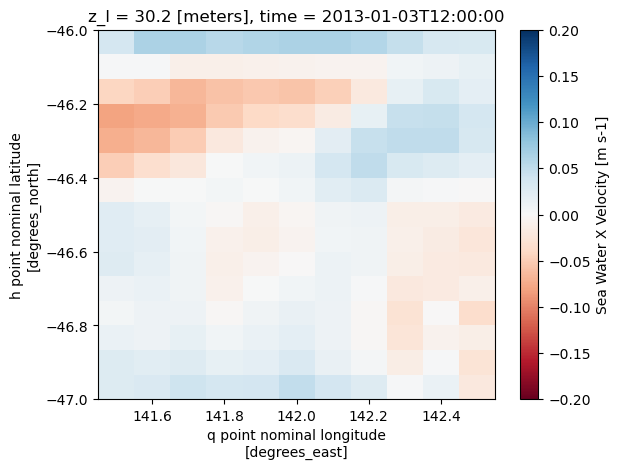

In [53]:
ds.uo.isel(time=-1, z_l=5).plot(vmin = -0.2, vmax = 0.2, cmap = 'RdBu')

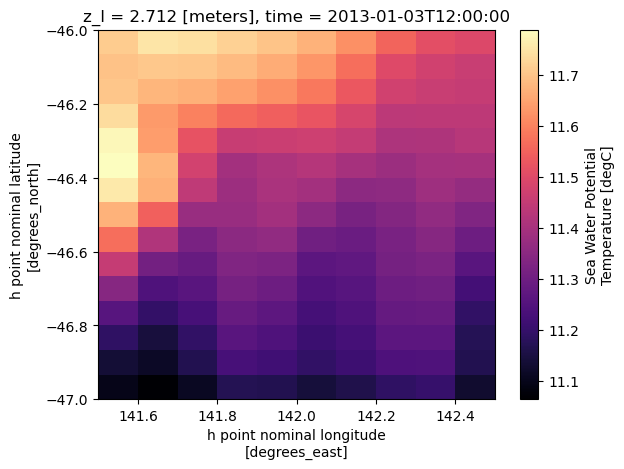

In [51]:
ds.thetao.isel(time=-1, z_l=0).plot(cmap = 'magma')